In [1]:
#imports
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


from LinearRegression import LinearRegression

# Linear regression in 1D


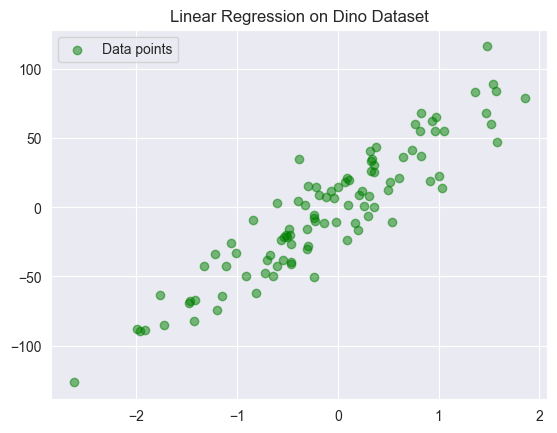

In [2]:
# Generate data with 1 feature
X, y = datasets.make_regression(n_samples=100, n_features=1, noise=20, random_state=42)

# Plot raw data
plt.scatter(X, y, color='green', label='Data points', alpha=0.5)
plt.title('Linear Regression on Dino Dataset')
plt.legend()
plt.show()

In [3]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# Train the model and predict
reg = LinearRegression()
reg.fit(X_train, y_train)
predictions = reg.predict(X_test)

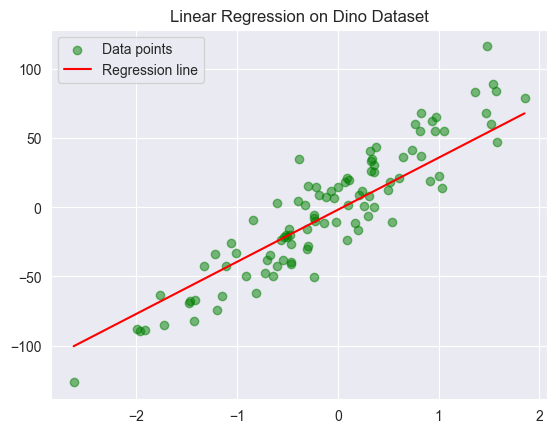

In [5]:
plt.scatter(X, y, color='green', label='Data points', alpha=0.5)
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = reg.predict(x_line)
plt.plot(x_line, y_line, color='red', label='Regression line')
plt.title('Linear Regression on Dino Dataset')
plt.legend()
plt.show()

In [6]:
# Evaluate the model
mse_value = np.mean((y_test - predictions) ** 2)
rmse = np.sqrt(np.mean((y_test - predictions) ** 2))
mae = np.mean(np.abs(y_test - predictions))
r2 = 1 - (np.sum((y_test - predictions) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

print(f"MSE: {mse_value:.4f}\n")
print(f"RMSE: {rmse:.4f}\n")
print(f"MAE: {mae:.4f}\n")
print(f"R-squared: {r2:.4f}")

MSE: 536.6077

RMSE: 23.1648

MAE: 18.5688

R-squared: 0.7450


# Multi-Feature Regression

In [7]:
# Generate data with 4 features
X, y = datasets.make_regression(n_samples=100, n_features=4, noise=20, random_state=42)

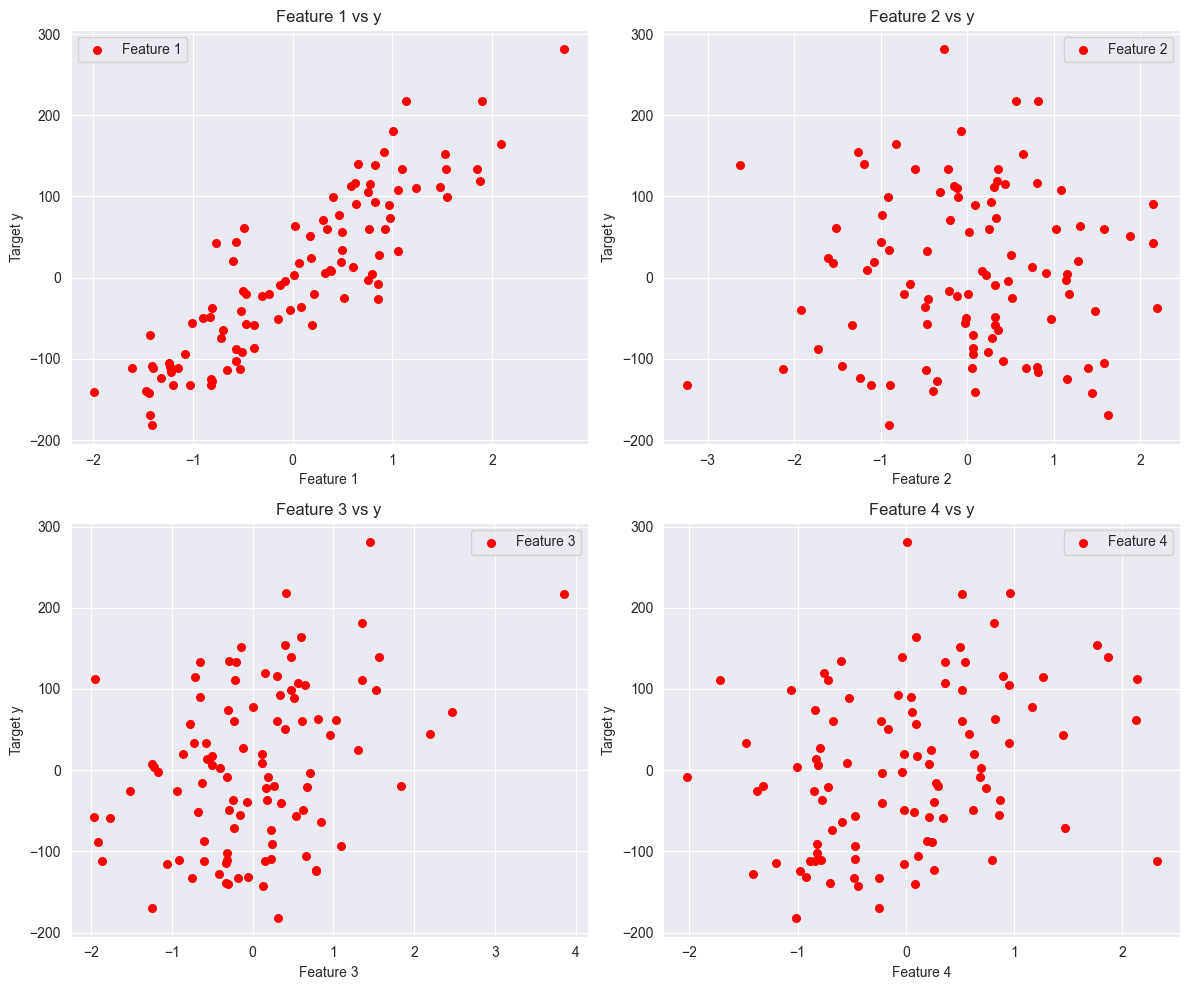

In [8]:
# Visualize each feature vs y
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
for i, ax in enumerate(axs.flat):
    if i < X.shape[1]:
        ax.scatter(X[:, i], y, color="red", s=30, label=f"Feature {i+1}")
        ax.set_xlabel(f"Feature {i+1}")
        ax.set_ylabel("Target y")
        ax.set_title(f"Feature {i+1} vs y")
        ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Split, train, and predict
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg_multi = LinearRegression()
reg_multi.fit(X_train, y_train)
predictions_multi = reg_multi.predict(X_test)

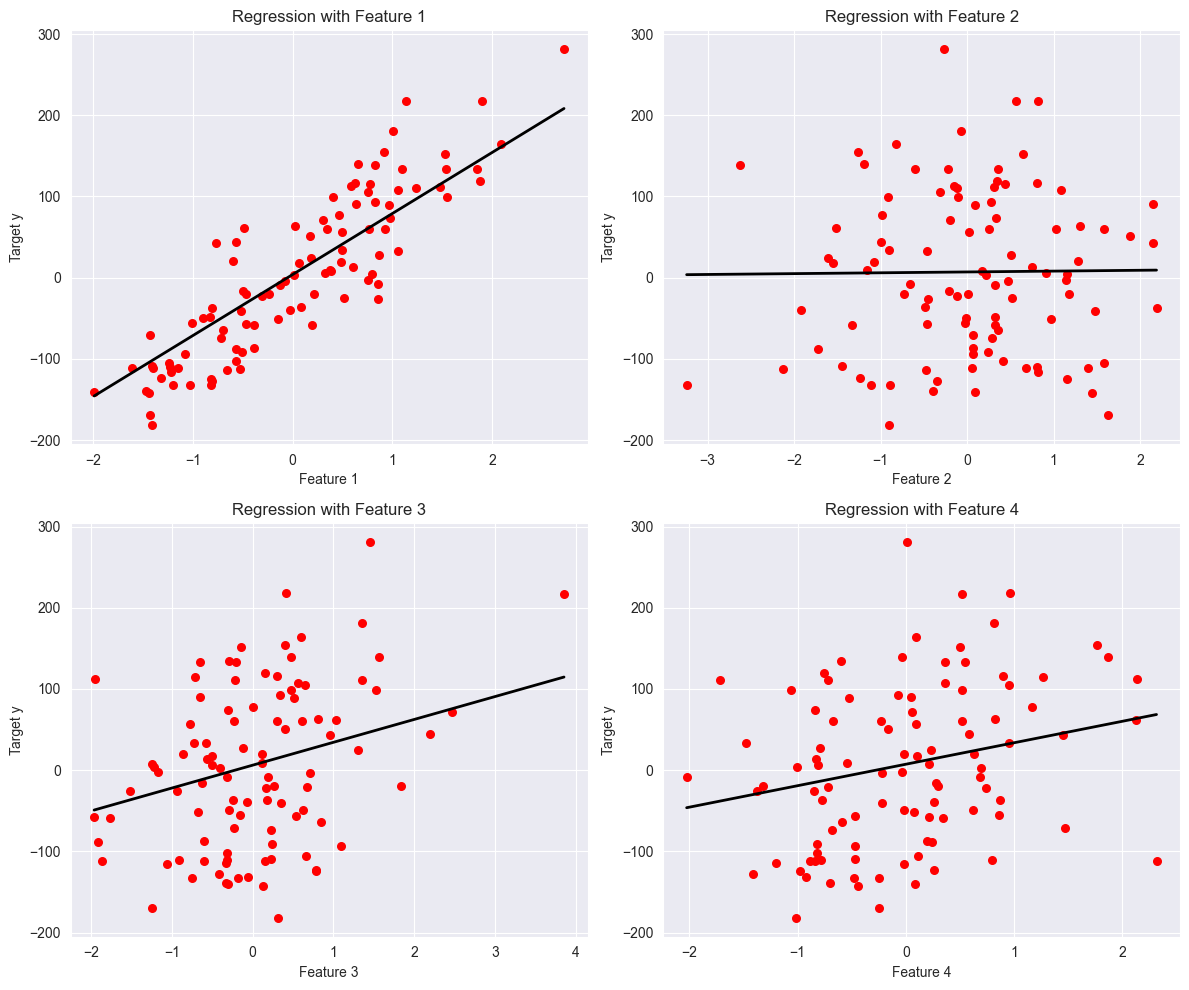

In [10]:
# Visualize predictions vs actual for multiple features with hyperplane intersection
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
for i, ax in enumerate(axs.flat):
    if i < X.shape[1]:
        ax.scatter(X[:, i], y, color="red", s=30)
        x_range = np.linspace(X[:, i].min(), X[:, i].max(), 100)
        X_range = np.tile(X.mean(axis=0), (100, 1))
        X_range[:, i] = x_range
        y_range_pred = reg_multi.predict(X_range)
        ax.plot(x_range, y_range_pred, color="black", linewidth=2)
        ax.set_xlabel(f"Feature {i+1}")
        ax.set_ylabel("Target y")
        ax.set_title(f"Regression with Feature {i+1}")
plt.tight_layout()
plt.show()

In [11]:
# Calculate error metrics for multi-feature model
mse_multi = np.mean((y_test - predictions_multi) ** 2)
rmse_multi = np.sqrt(np.mean((y_test - predictions_multi) ** 2))
mae_multi = np.mean(np.abs(y_test - predictions_multi))
r2_multi = 1 - (np.sum((y_test - predictions_multi) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

print(f"Multi-Feature Model Metrics:")
print(f"MSE: {mse_multi:.4f}")
print(f"RMSE: {rmse_multi:.4f}")
print(f"MAE: {mae_multi:.4f}")
print(f"R-squared: {r2_multi:.4f}")

Multi-Feature Model Metrics:
MSE: 910.9156
RMSE: 30.1814
MAE: 25.0593
R-squared: 0.8641


# Blind regression

In [12]:
# Load data
url = "https://raw.githubusercontent.com/probml/probml-data/main/data/DatasaurusDozen.tsv"
df = pd.read_csv(url, sep="\t")
dino = df[ df["dataset"] == "dino" ].drop(columns=['dataset'])
print(dino.head())

         x        y
0  55.3846  97.1795
1  51.5385  96.0256
2  46.1538  94.4872
3  42.8205  91.4103
4  40.7692  88.3333


In [13]:
X = dino["x"].to_numpy().reshape(-1, 1)
y = dino["y"].to_numpy()

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Fit the model
reg = LinearRegression(lr=0.0000644)
reg.fit(X_train, y_train)
predictions = reg.predict(X_test)

The error say the default lr is too large; perhaps set it to 0.0000644?

In [15]:
# Evaluate model
mse_value = np.mean((y_test - predictions) ** 2)
rmse = np.sqrt(np.mean((y_test - predictions) ** 2))
mae = np.mean(np.abs(y_test - predictions))
r2 = 1 - (np.sum((y_test - predictions) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

print(f"MSE: {mse_value:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R-squared: {r2:.4f}")

MSE: 1135.4254
RMSE: 33.6961
MAE: 29.8830
R-squared: -0.5919


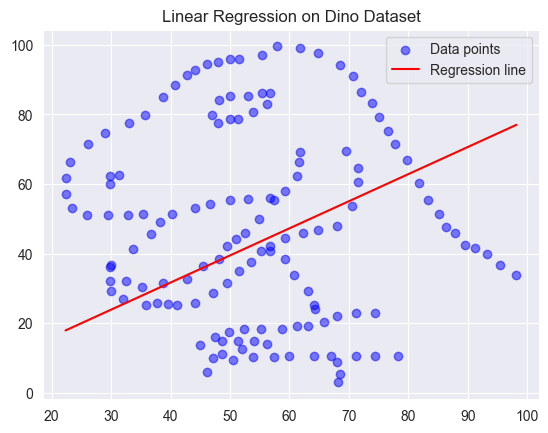

In [16]:
plt.scatter(X, y, color='blue', label='Data points', alpha=0.5)
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = reg.predict(x_line)
plt.plot(x_line, y_line, color='red', label='Regression line')
plt.title('Linear Regression on Dino Dataset')
plt.legend()
plt.show()